# Pipeline EHBG-FACS · 02 · Metaheurísticas (ACO y Tabu)

**Paradigma 2 — implementaciones oficiales de SVRPBench, re-puntuadas con CRN.**

Envuelve el **Ant System** y la **Tabu Search** oficiales del benchmark (con arranque NN+2opt) y re-puntúa sus rutas con el evaluador compartido, para que sean comparables con el resto. Agregación best-of-K (multistart) determinista por instancia.

In [ ]:
# === Configuración del entorno (ejecuta esta celda primero) =================
# Requiere: (a) el paquete `svrplab` (carpeta experiments/colab del repo de tesis)
#           (b) el repo oficial de SVRPBench (se clona solo en bootstrap.init()).
REPO_URL  = "https://github.com/AbrahamHub/TESIS-ANT"   # <-- EDITA si tu repo difiere
USE_DRIVE = True   # persistir banco/resultados/modelos en Google Drive (recomendado)

import os, sys, subprocess

if USE_DRIVE:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
    except Exception as e:
        print("Drive no disponible (¿ejecutas local?):", e)

def _find_svrplab():
    cands = ["/content/drive/MyDrive/TESIS-ANT/experiments/colab",
             "/content/TESIS-ANT/experiments/colab",
             os.path.join(os.getcwd(), "experiments", "colab"),
             os.getcwd()]
    for c in cands:
        if os.path.isdir(os.path.join(c, "svrplab")):
            return c
    return None

_path = _find_svrplab()
if _path is None:
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL, "/content/TESIS-ANT"], check=False)
    _path = "/content/TESIS-ANT/experiments/colab"
sys.path.insert(0, _path)
print("svrplab en:", _path)

subprocess.run([sys.executable, "-m", "pip", "install", "-q", "numpy", "scipy", "pandas",
                "matplotlib", "scikit-learn", "pillow", "tqdm"], check=False)
# torch ya viene en Colab. gurobipy solo se instala en el notebook del paradigma 1.

from svrplab import bootstrap, protocol, data, runner, metrics, viz
env   = bootstrap.init()        # GPU + repo oficial SVRPBench + rutas (Drive si está montado)
proto = protocol.DEFAULT
print("device:", env.device, "| raíz de artefactos:", env.paths.root)

Mounted at /content/drive
svrplab en: /content/TESIS-ANT/experiments/colab
[bootstrap] repo oficial ya presente en /content/drive/MyDrive/EHBG_FACS/svrpbench
[bootstrap] GPU detectada: Tesla T4 (14.6 GB) | torch 2.11.0+cu128 CUDA 12.8
[bootstrap] raíz de artefactos: /content/drive/MyDrive/EHBG_FACS
[bootstrap] results/ figures/ data/ listos | seed=12345 device=cuda
device: cuda | raíz de artefactos: /content/drive/MyDrive/EHBG_FACS


In [ ]:
# === Configuración del experimento (IDÉNTICA en los 5 notebooks) ============
# Para garantizar el "piso parejo", TODOS los notebooks deben usar los MISMOS
# SIZES y N_INSTANCES: así resuelven exactamente el mismo banco de instancias.
SIZES       = [10, 20, 50, 100, 200, 300]           # clientes. Extiende a [50,100,200,300] (ver notas).
N_INSTANCES = 5   # 30 (rigor estadístico). Corrida rápida: pon 5.

bank = data.load_bank(env.paths.instances, SIZES, N_INSTANCES,
                      base_seed=proto.base_seed, capacity_mode=proto.capacity_mode, verbose=True)
print({s: len(v) for s, v in bank.items()}, "instancias por tamaño")

OR-Tools not available: No module named 'ortools'
[data] n=10: 30 instancias (cache) -> bank_n10_m30_s12345_binding.npz
[data] n=20: 30 instancias (cache) -> bank_n20_m30_s12345_binding.npz
[data] n=50: 30 instancias (cache) -> bank_n50_m30_s12345_binding.npz
{10: 30, 20: 30, 50: 30} instancias por tamaño


## Resolver ACO y Tabu

In [ ]:
from svrplab.solvers.metaheuristic import ACO, Tabu
import pandas as pd
df_aco  = runner.run_solver(ACO(n_seeds=5),  "aco",  bank, env, proto, verbose=True)
df_tabu = runner.run_solver(Tabu(n_seeds=5), "tabu", bank, env, proto, verbose=True)
df = pd.concat([df_aco, df_tabu], ignore_index=True)
df

  [aco] n=10 inst=0: E[c]=2232.6 E[c+Q]=2232.6 CVaR=2232.9 feas=1.00 veh=4 t=0.742s (wall 1.2s)
  [aco] n=10 inst=1: E[c]=3148.8 E[c+Q]=3148.8 CVaR=3149.1 feas=1.00 veh=6 t=1.078s (wall 1.9s)
  [aco] n=10 inst=2: E[c]=3678.9 E[c+Q]=3678.9 CVaR=3679.2 feas=1.00 veh=6 t=1.245s (wall 2.2s)
  [aco] n=10 inst=3: E[c]=3411.0 E[c+Q]=3411.0 CVaR=3411.4 feas=1.00 veh=6 t=0.745s (wall 1.3s)
  [aco] n=10 inst=4: E[c]=2858.9 E[c+Q]=2858.9 CVaR=2859.2 feas=1.00 veh=7 t=0.926s (wall 1.5s)
  [aco] n=10 inst=5: E[c]=3047.8 E[c+Q]=3047.8 CVaR=3048.1 feas=1.00 veh=5 t=0.897s (wall 1.4s)
  [aco] n=10 inst=6: E[c]=3563.0 E[c+Q]=3563.0 CVaR=3563.2 feas=1.00 veh=6 t=0.506s (wall 0.9s)
  [aco] n=10 inst=7: E[c]=3822.9 E[c+Q]=3848.1 CVaR=3848.5 feas=0.00 veh=5 t=0.434s (wall 0.8s)
  [aco] n=10 inst=8: E[c]=4302.0 E[c+Q]=4340.6 CVaR=4340.9 feas=0.00 veh=7 t=0.442s (wall 0.8s)
  [aco] n=10 inst=9: E[c]=3488.9 E[c+Q]=3488.9 CVaR=3489.3 feas=1.00 veh=5 t=0.721s (wall 1.2s)
  [aco] n=10 inst=10: E[c]=3879.0 E[c+Q]

,solver,paradigm,size,instance,seed,det_cost,expected_cost,expected_total,cvar,feasibility,cvr,robustness,tw_violations,runtime,train_time_s,gap,n_vehicles
0,aco,2,10,0,22345,NaN,2232.625639,2232.625639,2232.898937,1.0,0.0,0.133560,0.0,0.741512,NaN,NaN,4
1,aco,2,10,1,22346,NaN,3148.791483,3148.791483,3149.107413,1.0,0.0,0.138878,0.0,1.078051,NaN,NaN,6
2,aco,2,10,2,22347,NaN,3678.889506,3678.889506,3679.236111,1.0,0.0,0.152025,0.0,1.244942,NaN,NaN,6
3,aco,2,10,3,22348,NaN,3411.034385,3411.034385,3411.363855,1.0,0.0,0.153184,0.0,0.745255,NaN,NaN,6
4,aco,2,10,4,22349,NaN,2858.919236,2858.919236,2859.221513,1.0,0.0,0.150593,0.0,0.925591,NaN,NaN,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,tabu,2,50,25,62370,NaN,17719.084784,17719.084784,17719.870993,1.0,0.0,0.341039,0.0,13.548274,NaN,NaN,33
176,tabu,2,50,26,62371,NaN,19696.059359,19696.059359,19696.708493,1.0,0.0,0.329751,0.0,13.155922,NaN,NaN,32
177,tabu,2,50,27,62372,NaN,25867.647498,25868.468104,25869.276944,0.0,2.0,0.372963,1.0,15.571625,NaN,NaN,34
178,tabu,2,50,28,62373,NaN,14981.079235,15057.043383,15057.745853,0.0,2.0,0.328258,1.0,10.934285,NaN,NaN,27


## Métricas y figuras

,solver,size,det_cost,expected_cost,expected_total,cvar,feasibility,cvr,robustness,tw_violations,runtime,train_time_s,gap,n_vehicles,expected_cost_std,expected_total_std,cvar_std
0,aco,10,NaN,3406.756190,3412.078511,3412.572106,0.833333,1.666667,0.284742,0.166667,0.643961,NaN,NaN,6.000000,653.054170,655.581741,655.659569
1,aco,20,NaN,7521.123088,7530.546639,7530.998682,0.900000,0.666667,0.212394,0.133333,1.719043,NaN,NaN,12.600000,1290.764886,1289.845573,1289.851825
2,aco,50,NaN,17203.751983,17215.016884,17217.608486,0.699833,0.600333,1.643615,0.300167,9.785366,NaN,NaN,27.666667,2612.193095,2618.392984,2618.909255
3,tabu,10,NaN,3699.597088,3704.919409,3705.245896,0.833333,1.666667,0.148387,0.166667,2.045870,NaN,NaN,6.133333,768.377784,769.455164,769.472100
4,tabu,20,NaN,8244.233876,8253.657428,8254.116719,0.900000,0.666667,0.215208,0.133333,5.283188,NaN,NaN,12.200000,1346.424404,1342.680514,1342.684899
5,tabu,50,NaN,20782.642398,20793.906619,20795.918418,0.700000,0.600000,1.237802,0.300000,12.680624,NaN,NaN,32.400000,3037.131402,3044.257970,3045.105274


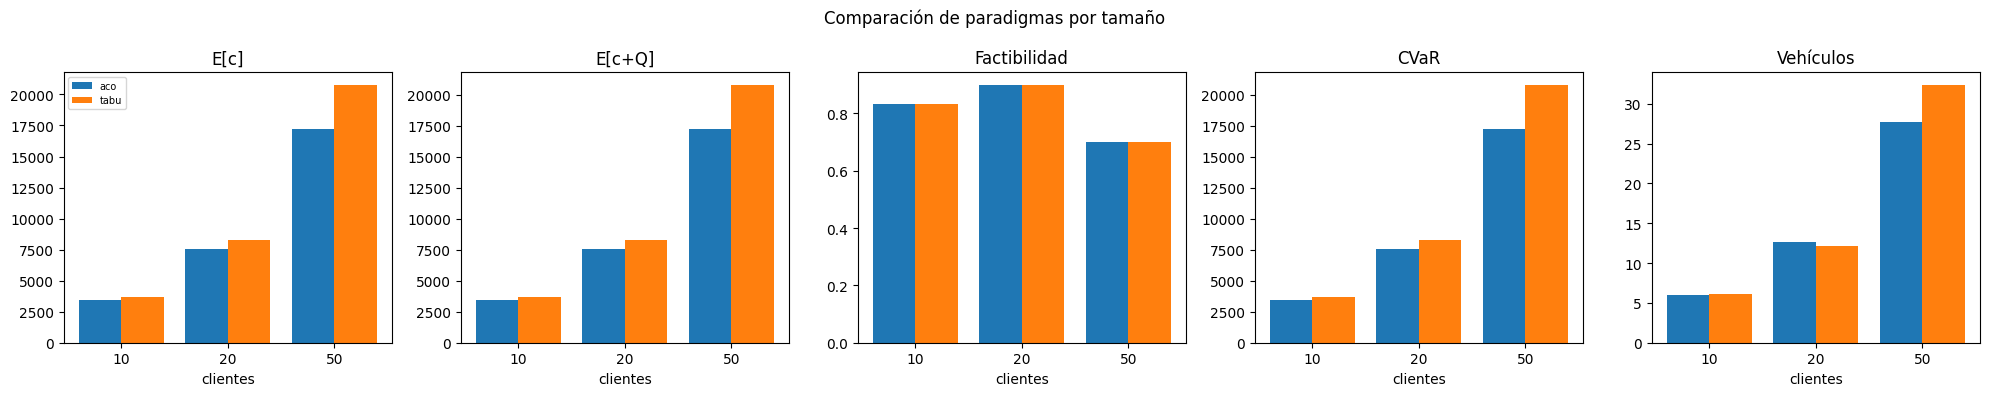

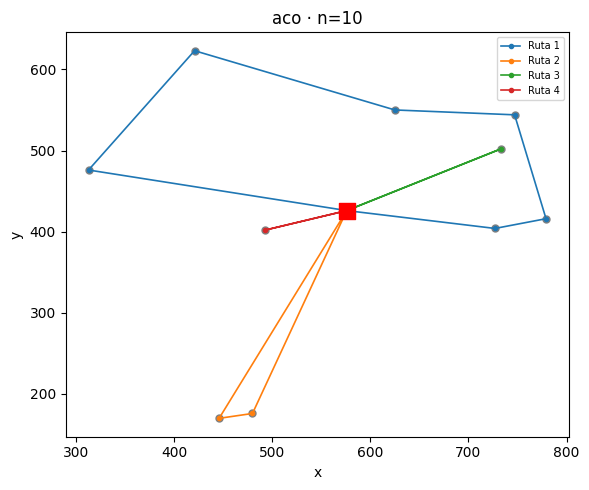

In [ ]:
display(metrics.aggregate_by_size(df))
import matplotlib.pyplot as plt
viz.plot_comparison(df); plt.show()
inst = bank[SIZES[0]][0]
sol = ACO(n_seeds=5).solve(inst, num_realizations=proto.realizations)
viz.plot_routes(inst, sol.routes, title=f"aco · n={SIZES[0]}"); plt.show()

**Interpretación.** Las metaheurísticas alcanzan **factibilidad alta** pero usando **más vehículos** (rutas cortas) y, por tanto, mayor costo: la otra familia del tradeoff.